In [2]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

%matplotlib inline

First a bit of notation.   The symbol to the left of the semicolon is the variable which we are measuring or using as an input to the function.  In the equation below, this is $x$.  The symbols to the right of the semicolon are known.   Below, these are $\mu$ and $\sigma$.
This if often read as “$f$ as a function of $x$ parameterized by $\mu$ and $\sigma$” or “$f$ as a function of $x$ given $\mu$ and $\sigma$”

\begin{equation}
f(x; \mu, \sigma) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(
    \frac{x-\mu}{\sigma} \right)^2}
\label{eq:likelihood}
\end{equation}

To reiterate, we are measuring $x$ and we already know $\mu$ and $\sigma$.

In [5]:
mu  = 175
sigma = 5

x = [170, 190]

norm.pdf(x, mu, sigma)

array([0.04839414, 0.00088637])

The problem we want to solve is the reverse.  We write,

\begin{equation}
f(\mu, \sigma; x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(
    \frac{x-\mu}{\sigma} \right)^2}
\end{equation}

We want to find $\mu$ and $\sigma$ given some data $x$.  The issue is we don’t know either $\mu$ or $\sigma$ so we need a way to estimate these.

One way of doing this is known as maximum likelihood estimation.



In [9]:
np.random.seed(31)

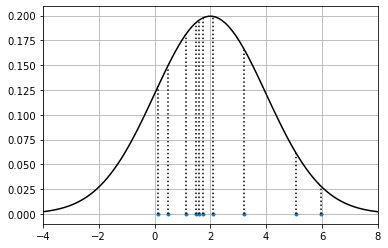

In [12]:
N = 10

mu = 2
sigma = 2

X = np.linspace(-4, 8, 100)
Y = norm.pdf(X, mu, sigma)
plt.plot(X, Y, 'k')

x = np.random.normal(mu, sigma, size = (N,))
plt.plot(x, np.zeros(x.shape), '.')
plt.xlim(np.amin(X), np.amax(X))

for i in range(x.size):
    plt.plot((x[i], x[i]), (0, norm.pdf(x[i], mu, sigma)), 'k:'  )
    
plt.grid()
plt.savefig('collection_of_points.png')

Since points seen to cluster where the likelihood is a maximum, we will coohse $\mu$, and $\sigma$ such that we maximize the likelihood give our observed data.

In calculus, we find the maxiumum of a function by taking its derivative with respect to our variable of interest, and setting it to zero.  We then solve the equation for our variable.

$$f = f(x_1)f(x_2)...f(x_{N-1})f(x_N) = \prod_{i = 1}^N f(x_i)$$

So, for our problem,
$$
f(\mu, \sigma; x_1...x_N) = \prod_{i=1}^N \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(
    \frac{x_i-\mu}{\sigma} \right)^2}
$$

$$\log(AB) = \log(A) + \log(B)$$

$$
\log(f(\mu, \sigma; x_1...x_N)) = \log\left[\prod_{i=1}^N \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(
    \frac{x_i-\mu}{\sigma} \right)^2}\right]
$$

This becomes

$$
\log(f(\mu, \sigma; x_1...x_N)) = \sum_{i=1}^N\left[ \log \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(
    \frac{x_i-\mu}{\sigma} \right)^2}\right]
$$

$$\frac{d}{d\mu}\sum_{i=1}^N\left[ \log \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(
    \frac{x_i-\mu}{\sigma} \right)^2}\right] = 0$$
    
This becomes,
    
$$\frac{d}{d\mu}\sum_{i=1}^N\left[ \log \left(\frac{1}{\sigma \sqrt{2\pi}}\right)  + \log \left(e^{-\frac{1}{2}\left(
    \frac{x_i-\mu}{\sigma} \right)^2}\right)\right] = 0$$
    
$$\frac{d}{d\mu}\sum_{i=1}^N\left[ \log \left(\frac{1}{\sigma \sqrt{2\pi}}\right)  + \left(-\frac{1}{2}\left(
    \frac{x_i-\mu}{\sigma} \right)^2\right)\right] = 0$$
    
$$\frac{d}{d\mu}\sum_{i=1}^N\left(-\frac{1}{2}\left(
    \frac{x_i-\mu}{\sigma} \right)^2\right) = 0$$
    
$$\sum_{i=1}^N -\left(
    \frac{x_i-\mu}{\sigma} \right)\left(\frac{-1}{\sigma}\right) = 0$$
    
$$\sum_{i=1}^N (x_i-\mu) = 0$$

$$\sum_{i=1}^N x_i - \sum_{i=1}^N \mu = 0$$

$$\sum_{i=1}^N x_i - N \mu = 0$$

$$\mu = \frac{1}{N}\sum_{i=1}^N x_i$$